## Improting Libs

In [1]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns

&nbsp;

In [2]:
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

&nbsp;



In [3]:
import tensorflow as tf
from tensorflow import keras

&nbsp;

## Data Loading

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

print("Path to dataset files:", path)

100%|██████████| 1.17G/1.17G [00:14<00:00, 85.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1


In [8]:
full_dir = '/content/1/chest_xray/dataset'

In [14]:
print(len(os.listdir(os.path.join(full_dir, 'NORMAL'))))
print(len(os.listdir(os.path.join(full_dir, 'PNEUMONIA'))))
print(f'Total Data: {len(os.listdir(os.path.join(full_dir, 'NORMAL'))) + len(os.listdir(os.path.join(full_dir, 'PNEUMONIA')))}')

1583
4273
Total Data: 5856


&nbsp;

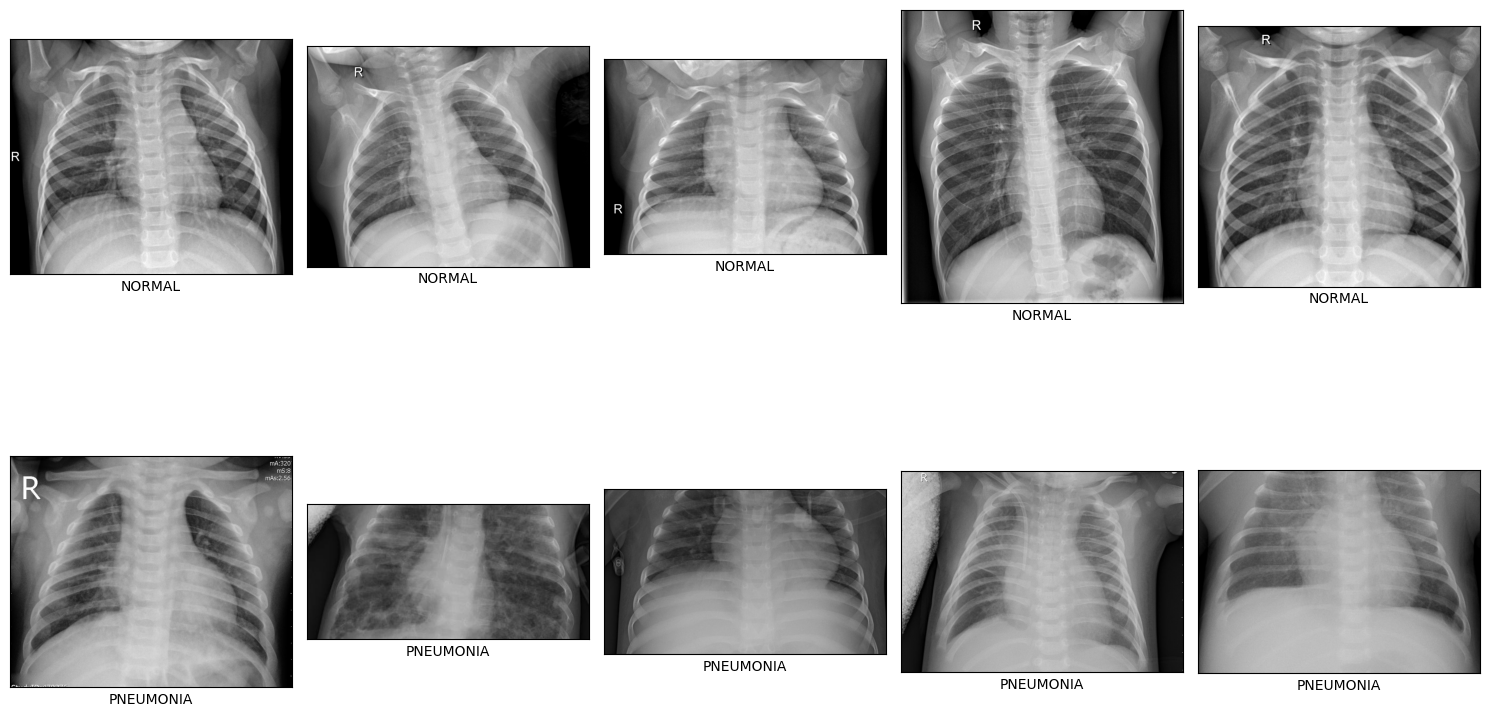

In [16]:
# Showing 5 random image from the full dataset
lung_image = {}

for i in os.listdir(full_dir):
  lung_image[i] = os.listdir(os.path.join(full_dir, i))

fig, axs = plt.subplots(2, 5, figsize=(15, 10))

for i, class_name in enumerate(lung_image.keys()):
  for j, image_name in enumerate(sample(lung_image[class_name], 5)):
    img = Image.open(os.path.join(full_dir, class_name, image_name))
    axs[i, j].imshow(img, cmap='gray')
    axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

plt.tight_layout()
plt.show()


&nbsp;

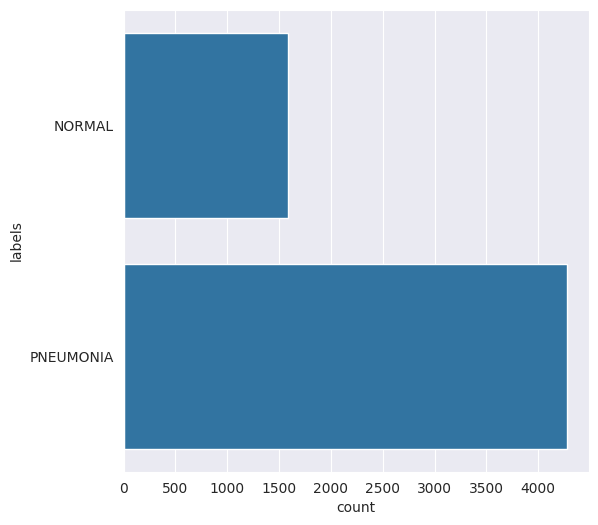

In [17]:
# Plotting the distribution
file_name = []
labels = []
paths = []

for path, subdirs, files in os.walk(full_dir):
    for name in files:
        paths.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_dir, 'file_name':file_name, "labels":labels})

Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)


&nbsp;

In [18]:
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, sudut)

def clockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, -sudut)

def flip_up_down(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return np.flipud(img)

def add_brightness(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    img = adjust_gamma(img, gamma=0.5,gain=1)
    return img

def blur_image(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return cv2.GaussianBlur(img, (9,9),0)

def sheared(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(shear=0.2)
    shear_image = warp(img, transform, mode="wrap")
    return shear_image

def warp_shift(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(translation=(0,40))
    warp_image = warp(img, transform, mode="wrap")
    return warp_image

In [19]:
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

In [33]:
# augmenting 2000 image from the dataset and put it in augmented folder
# keeping the name for labeling purpose with _aug_ suffix

augmented_path = '/content/1/chest_xray/AUGMENTED'
if not os.path.exists(augmented_path):
    os.makedirs(augmented_path)

# Collect all image paths
all_images = []
for root, dirs, files in os.walk(Path(full_dir) / 'NORMAL'):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

images_to_generate = 2000
i = 1

print(f"Starting augmentation of {images_to_generate} images...")

while i <= images_to_generate:
    image_path = random.choice(all_images)
    try:
        # Get the original filename
        base_name = os.path.splitext(os.path.basename(image_path))[0]

        original_image = cv2.imread(image_path)
        if original_image is None:
            continue

        transformed_image = original_image
        transformation_count = random.randint(1, len(transformations))

        for _ in range(transformation_count):
            key = random.choice(list(transformations.keys()))
            input_img = img_as_ubyte(transformed_image)
            transformed_image = transformations[key](input_img)

        # Construct the new name
        filename = f"{base_name}_aug_{i}.jpg"
        new_image_path = os.path.join(augmented_path, filename)

        final_image = img_as_ubyte(transformed_image)
        cv2.imwrite(new_image_path, final_image)

        i += 1
    except Exception as e:
        print(f"Skipping {image_path} due to error: {e}")

Starting augmentation of 2000 images...


In [34]:
len(os.listdir(augmented_path))

4409

In [35]:
augmented_dir = '/content/1/chest_xray/AUGMENTED'
dataset_dir = '/content/1/chest_xray/dataset'

normal_dest = os.path.join(dataset_dir, 'NORMAL')
pneumonia_dest = os.path.join(dataset_dir, 'PNEUMONIA')

os.makedirs(normal_dest, exist_ok=True)
os.makedirs(pneumonia_dest, exist_ok=True)

count_normal = 0
count_pneumonia = 0

for filename in os.listdir(augmented_dir):
    file_path = os.path.join(augmented_dir, filename)
    if os.path.isfile(file_path):
        upper_name = filename.upper()

        # Determine category based on filename
        if 'NORMAL' in upper_name:
            shutil.copy(file_path, os.path.join(normal_dest, filename))
            count_normal += 1
        elif 'BACTERIA' in upper_name:
            shutil.copy(file_path, os.path.join(pneumonia_dest, filename))
            count_pneumonia += 1

print(f"Finished copying. Successfully moved {count_normal} to NORMAL and {count_pneumonia} to PNEUMONIA.")

Finished copying. Successfully moved 2943 to NORMAL and 980 to PNEUMONIA.


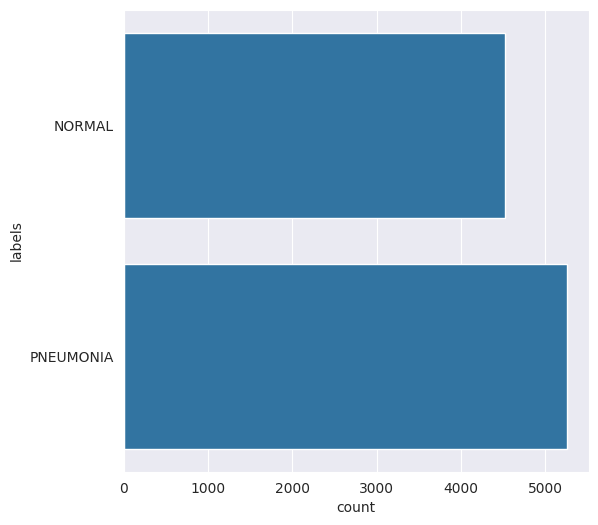

In [36]:
# Plotting the distribution after augmentation
file_name = []
labels = []
paths = []

for path, subdirs, files in os.walk(full_dir):
    for name in files:
        paths.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_dir, 'file_name':file_name, "labels":labels})

Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)


## Data Splitting

In [37]:
file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(full_dir):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
df.groupby(['labels']).size()

,0
labels,
NORMAL,4526
PNEUMONIA,5253


In [51]:
total_files = sum([len(files) for r, d, files in os.walk('/content/1/chest_xray/dataset/')])
print(total_files)

9779


&nbsp;

In [39]:
from sklearn.model_selection import train_test_split
X= df['path']
y= df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [44]:
print(len(X_train))
print(len(X_test))
print('*=========*')

7823
1956
*=========*


In [45]:
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [46]:
df_tr

,path,labels,set
8375,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,train
8170,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,train
1277,/content/1/chest_xray/dataset/NORMAL/NORMAL-35...,NORMAL,train
8561,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,train
3642,/content/1/chest_xray/dataset/NORMAL/NORMAL-79...,NORMAL,train
...,...,...,...
1749,/content/1/chest_xray/dataset/NORMAL/NORMAL-11...,NORMAL,train
7146,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,train
5834,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,train
6625,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,train


In [47]:
df_te

,path,labels,set
4237,/content/1/chest_xray/dataset/NORMAL/NORMAL-25...,NORMAL,test
8035,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,test
7633,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,test
7377,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,test
5752,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,test
...,...,...,...
8312,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,test
5609,/content/1/chest_xray/dataset/PNEUMONIA/BACTER...,PNEUMONIA,test
1024,/content/1/chest_xray/dataset/NORMAL/NORMAL-38...,NORMAL,test
194,/content/1/chest_xray/dataset/NORMAL/NORMAL-93...,NORMAL,test


In [48]:
# Define the root directory for the split dataset
split_dir = '/content/1/chest_xray/final_dataset'
os.makedirs(split_dir, exist_ok=True)

def prepare_folders_and_copy(df, set_name):
    # Create set directory (train or test)
    set_path = os.path.join(split_dir, set_name)
    os.makedirs(set_path, exist_ok=True)

    for index, row in tq(df.iterrows(), total=len(df), desc=f"Copying {set_name} data"):
        category = row['labels']
        source_path = row['path']

        # Create category directory inside the set directory
        dest_dir = os.path.join(set_path, category)
        os.makedirs(dest_dir, exist_ok=True)

        # Copy file
        filename = os.path.basename(source_path)
        dest_path = os.path.join(dest_dir, filename)

        if os.path.exists(source_path):
            shutil.copyfile(source_path, dest_path)

# Execute for both dataframes
prepare_folders_and_copy(df_tr, 'TRAIN_DIR')
prepare_folders_and_copy(df_te, 'TEST_DIR')

print("Finished creating split directory structure.")

Copying TRAIN_DIR data:   0%|          | 0/7823 [00:00<?, ?it/s]

Copying TEST_DIR data:   0%|          | 0/1956 [00:00<?, ?it/s]

Finished creating split directory structure.


In [53]:
TRAIN_DIR = '/content/1/chest_xray/final_dataset/TRAIN_DIR'
TEST_DIR = '/content/1/chest_xray/final_dataset/TEST_DIR'

train_normal = os.path.join(TRAIN_DIR + '/NORMAL')
train_pneumonia = os.path.join(TRAIN_DIR + '/PNEUMONIA')
test_normal = os.path.join(TEST_DIR + '/NORMAL')
test_pneumonia = os.path.join(TEST_DIR + '/PNEUMONIA')

print("Total number of normal images in training set: ",len(os.listdir(train_normal)))
print("Total number of pneumonic images in training set: ",len(os.listdir(train_pneumonia)))
print("Total number of normal images in test set: ",len(os.listdir(test_normal)))
print("Total number of pneumonic images in test set: ",len(os.listdir(test_pneumonia)))

Total number of normal images in training set:  3625
Total number of pneumonic images in training set:  4198
Total number of normal images in test set:  901
Total number of pneumonic images in test set:  1055


&nbsp;

## Image Data Generator

In [54]:
datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='binary',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='binary',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='binary',
                                                  shuffle=False)

Found 6259 images belonging to 2 classes.
Found 1564 images belonging to 2 classes.
Found 1956 images belonging to 2 classes.


&nbsp;

## Model Building

In [56]:
# tf.keras.backend.clear_session()

model_1 = keras.Sequential()

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,1)))
model_1.add(keras.layers.BatchNormalization())
model_1.add(keras.layers.MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(keras.layers.Conv2D(32, (4, 4),padding='same', activation='relu'))
model_1.add(keras.layers.BatchNormalization())
model_1.add(keras.layers.MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(keras.layers.Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(keras.layers.BatchNormalization())
model_1.add(keras.layers.MaxPool2D((2, 2)))

# Flatten layer
model_1.add(keras.layers.Flatten())
# 1nd Dense Layer
model_1.add(keras.layers.Dense(128, activation = 'relu'))
# 1nd Dropout Layer
model_1.add(keras.layers.Dropout(0.5))
# 2nd Dense Layer
model_1.add(keras.layers.Dense(64, activation = 'relu'))
# 2nd Dropout Layer
model_1.add(keras.layers.Dropout(0.3))

# Final Dense layer => For output prediction 1 mean (binary class in dataset), sigmoid for binary cases
model_1.add(keras.layers.Dense(1, activation='sigmoid'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Summary of the Model Architecture
print(model_1.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,402,881 (5.35 MB)

 Trainable params: 1,402,689 (5.35 MB)

 Non-trainable params: 192 (768.00 B)

None


&nbsp;

In [57]:
count_normal, count_pneumonia = len(os.listdir(train_normal)), len(os.listdir(train_pneumonia))
weight_0 = (1 / count_normal) * (count_normal + count_pneumonia) / 2.0
weight_1 = (1 / count_pneumonia) * (count_pneumonia + count_normal) / 2.0

class_weights = {0 : weight_0, 1 : weight_1}

%time

# Fitting / training model
history_1 = model_1.fit(train_generator,
                        epochs=30,
                        batch_size=32,
                        validation_data=validation_generator,
                        class_weight = class_weights)


CPU times: user 6 µs, sys: 1 µs, total: 7 µs
Wall time: 10.5 µs
Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - accuracy: 0.7728 - loss: 0.7877 - val_accuracy: 0.5364 - val_loss: 9.6768
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 534s 3s/step - accuracy: 0.8477 - loss: 0.4166 - val_accuracy: 0.5364 - val_loss: 13.0227
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 528s 3s/step - accuracy: 0.8880 - loss: 0.3249 - val_accuracy: 0.7973 - val_loss: 0.5060
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 526s 3s/step - accuracy: 0.8934 - loss: 0.2747 - val_accuracy: 0.8734 - val_loss: 0.3257
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 515s 3s/step - accuracy: 0.9131 - loss: 0.2374 - val_accuracy: 0.8919 - val_loss: 0.2669
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.9187 - loss: 0.2085 - val_accuracy: 0.8664 - val_loss: 0.3932
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 509s 3s/step - accuracy: 0.9263 - loss: 0.1914 - val_accuracy: 0.8798 - val_loss: 0.2786
Epoch 8/30
196/196 ━━━━━━━━━━━━━

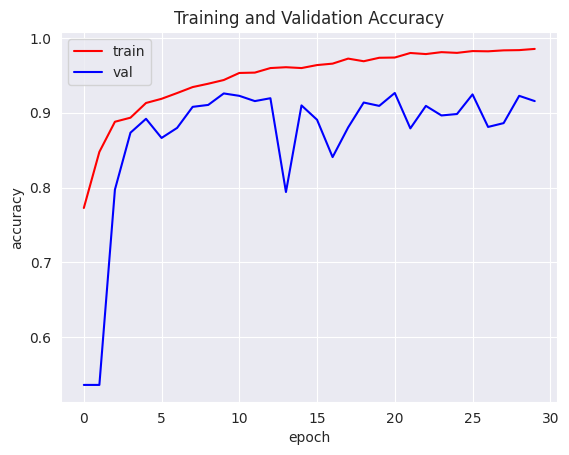

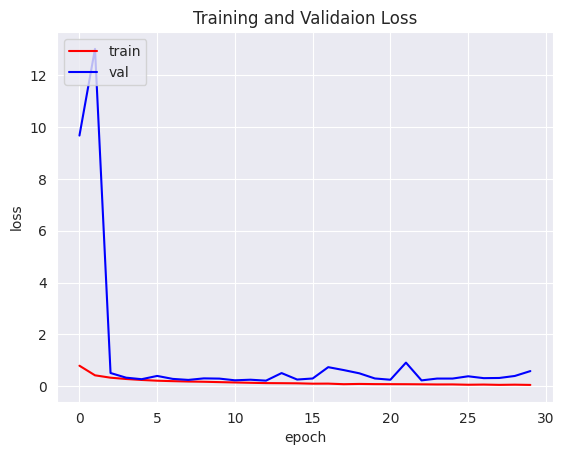

In [58]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()



              precision    recall  f1-score   support

      Normal     0.9484    0.8368    0.8892       901
   Pneumonia     0.8734    0.9611    0.9152      1055

    accuracy                         0.9039      1956
   macro avg     0.9109    0.8990    0.9022      1956
weighted avg     0.9080    0.9039    0.9032      1956



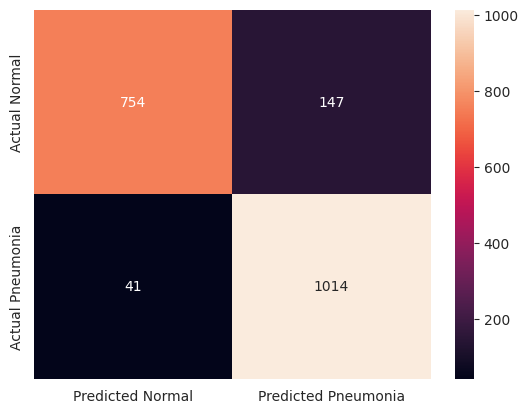

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
test_generator.reset()

preds_1 = model_1.predict(test_generator,verbose=0)
preds_1 = preds_1.copy()
preds_1[preds_1 <= 0.5] = 0
preds_1[preds_1 > 0.5] = 1

# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_1, labels=[0, 1]),index=["Actual Normal", "Actual Pneumonia"],
columns=["Predicted Normal", "Predicted Pneumonia"])
sns.heatmap(cm,annot=True,fmt="d")

# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=preds_1,target_names =['Normal','Pneumonia'], digits=4))
